In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#read in data
popular = pd.read_csv('high_popularity_spotify_data.csv')
unpopular = pd.read_csv('low_popularity_spotify_data.csv')

In [2]:
#combine the two datasets into one
df = pd.concat([popular, unpopular], axis=0, ignore_index=True)
df.head(10)

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.1220,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,0.000000,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.1170,0.438,Billie Eilish,4.0,0.0358,...,0.060800,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.1590,0.372,Gracie Abrams,4.0,0.0368,...,0.000000,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.3040,0.786,Sabrina Carpenter,4.0,0.0634,...,0.000000,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.3550,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,0.000000,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
5,0.582,116.712,0.700,pop,-5.960,0.0881,0.785,Chappell Roan,4.0,0.0356,...,0.000000,1WAjjRMfZjEXtB0lQrAw6Q,0.0,11.0,218424.0,0.0502,0WbMK4wrZ1wFSty9F7FCgu,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
6,0.561,150.069,0.669,pop,-6.538,0.0954,0.841,Addison Rae,4.0,0.0411,...,0.009620,0XA403JTounqFh2owquBXu,1.0,10.0,169698.0,0.4950,6MzofobZt2dm0Kf1hTThFz,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
7,0.247,148.101,0.467,pop,-12.002,0.1700,0.126,Billie Eilish,4.0,0.0431,...,0.000271,7aJuG4TFXa2hmE4z1yxc3n,0.0,6.0,261467.0,0.6120,3QaPy1KgI7nu9FJEQUgn6h,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
8,0.416,94.926,0.492,pop,-10.439,0.2030,0.297,Gigi Perez,4.0,0.0254,...,0.000086,4DWrYvfGXRE8ko5ZxlIpit,1.0,11.0,211979.0,0.6860,0UYnhUfnUj5adChuAXvLUB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
9,0.722,119.973,0.769,pop,-5.485,0.1110,0.570,"The Weeknd, Playboi Carti",4.0,0.0507,...,0.000003,2IRxVVqbSbqHJo8Zx50LYn,0.0,11.0,256000.0,0.0584,1Es7AUAhQvapIcoh3qMKDL,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


            energy        tempo  danceability     loudness     liveness  \
count  4830.000000  4830.000000   4830.000000  4830.000000  4830.000000   
mean      0.586691   118.269293      0.622311    -9.281627     0.167613   
std       0.246263    28.512615      0.187706     7.129396     0.124429   
min       0.000202    48.232000      0.058900   -48.069000     0.021000   
25%       0.442250    96.063000      0.525000   -10.297750     0.095400   
50%       0.633000   118.059500      0.653000    -7.191000     0.118000   
75%       0.777000   136.723500      0.758000    -5.336750     0.195000   
max       0.998000   241.426000      0.979000     1.318000     0.979000   

           valence  time_signature  speechiness  track_popularity  \
count  4830.000000     4830.000000  4830.000000       4831.000000   
mean      0.481930        3.936646     0.101738         54.761126   
std       0.258036        0.409712     0.101032         19.828573   
min       0.029600        1.000000     0.021900 

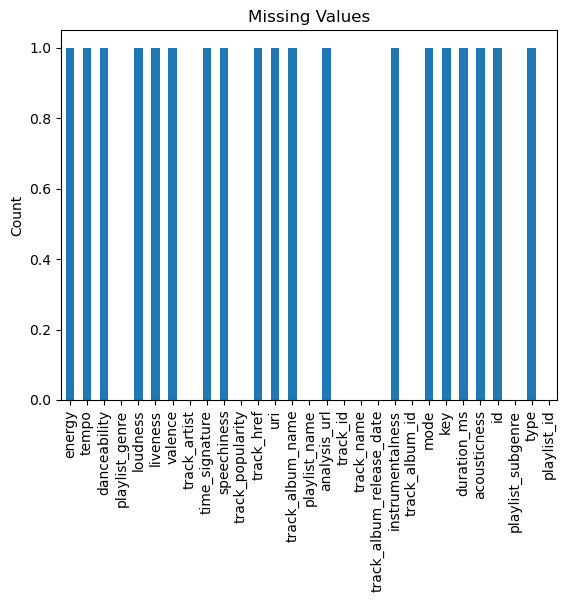

In [3]:
#general look at data
print(df.describe())
print(df.isnull().sum())

#visualize all missing values
missing = df.isnull().sum()
missing.plot(kind='bar')
plt.title('Missing Values')
plt.ylabel('Count')
plt.show()

In [4]:
#pick only the selected features + response variable
df_model = df[['track_popularity','loudness','energy','danceability','instrumentalness','acousticness','tempo','speechiness','valence']]
#drop rows with missing values (very few)
df_model = df_model.dropna()

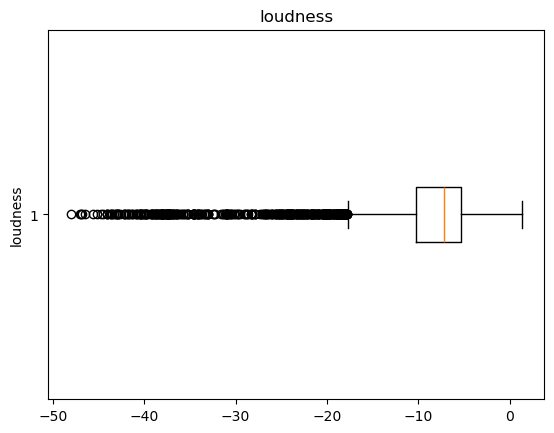

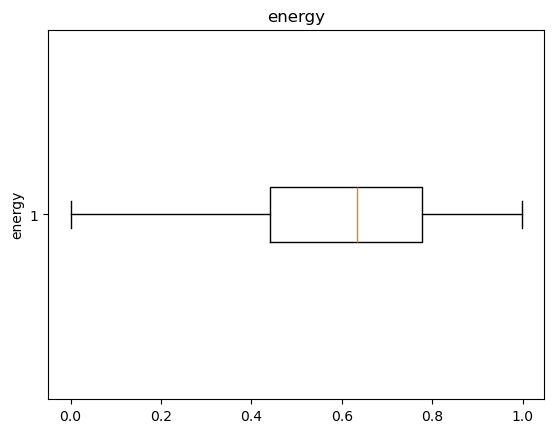

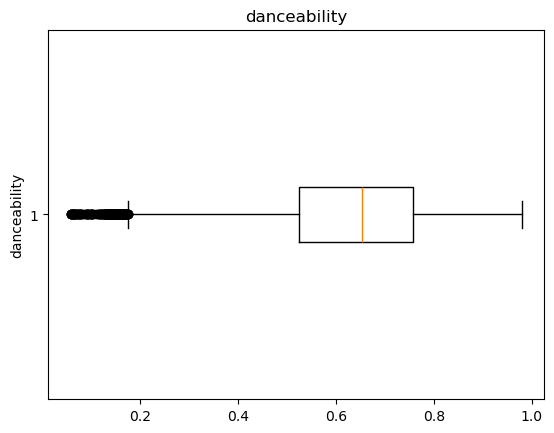

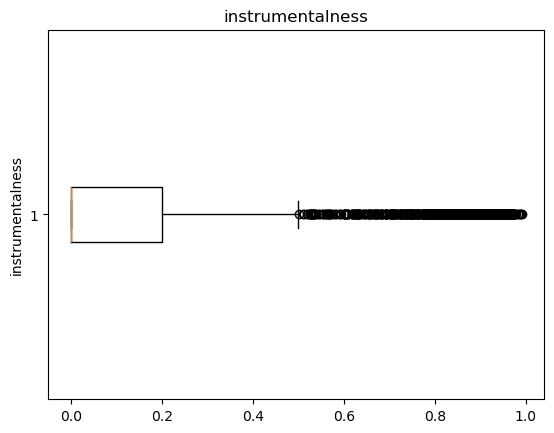

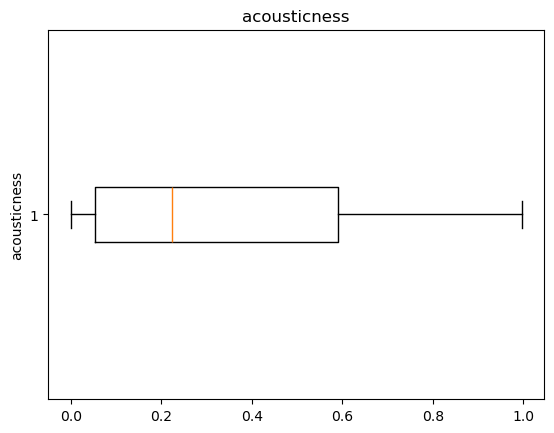

In [5]:
features = ['loudness', 'energy', 'danceability', 'instrumentalness', 'acousticness']
#look at chosen features for outliers
for col in features:
    plt.figure()
    plt.boxplot(df_model[col], vert=False)
    plt.title(col)
    plt.ylabel(col)
    plt.show()

We will not remove any outliers because they represent real variation in songs rather than error in data collection. 

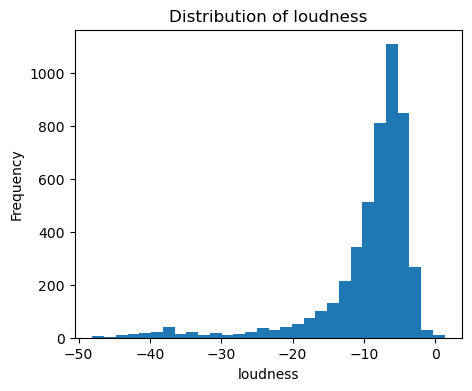

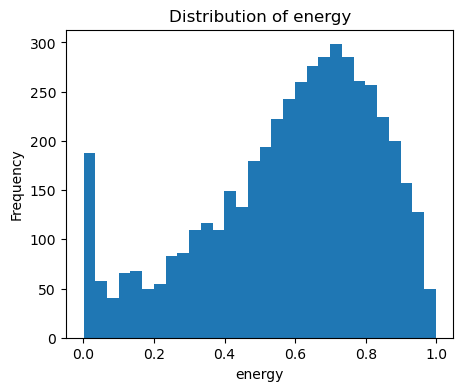

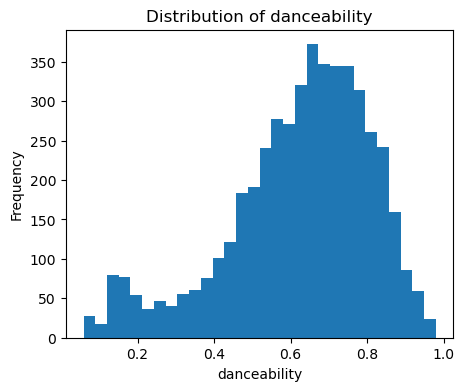

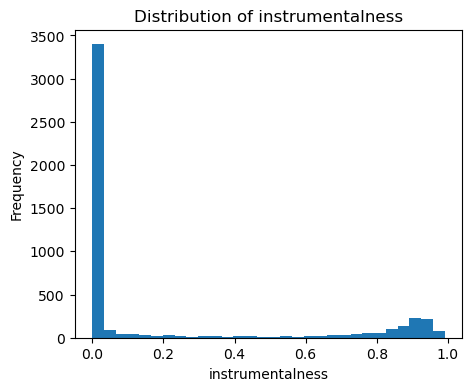

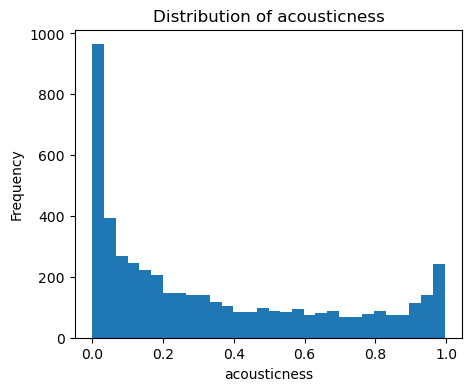

In [6]:
#look at distributions
for col in features:
    plt.figure(figsize=(5,4))
    plt.hist(df_model[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

We will not transform any data because the skewness observed in some of the variables is due to real world variation and should be represented. 

       track_popularity     loudness       energy  danceability  \
count       4830.000000  4830.000000  4830.000000   4830.000000   
mean          54.762112    -9.281627     0.586691      0.622311   
std           19.830508     7.129396     0.246263      0.187706   
min           11.000000   -48.069000     0.000202      0.058900   
25%           41.000000   -10.297750     0.442250      0.525000   
50%           56.000000    -7.191000     0.633000      0.653000   
75%           72.000000    -5.336750     0.777000      0.758000   
max          100.000000     1.318000     0.998000      0.979000   

       instrumentalness  acousticness        tempo  speechiness      valence  
count       4830.000000   4830.000000  4830.000000  4830.000000  4830.000000  
mean           0.201053      0.341217   118.269293     0.101738     0.481930  
std            0.351918      0.325382    28.512615     0.101032     0.258036  
min            0.000000      0.000004    48.232000     0.021900     0.029600  
2

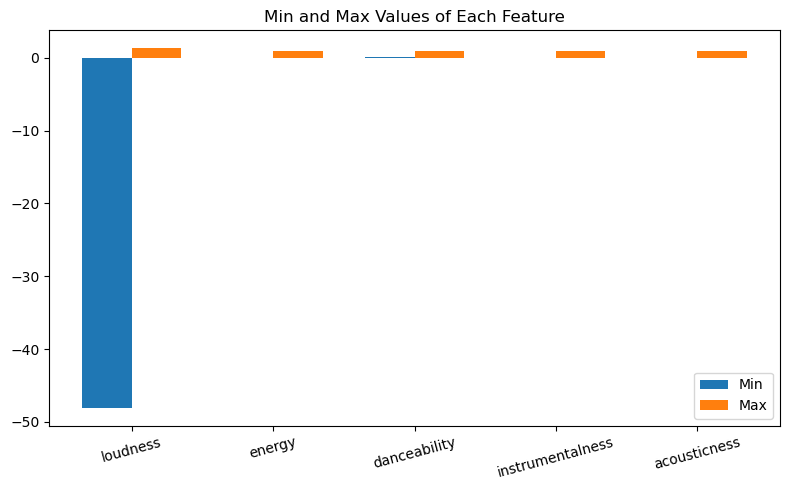

In [7]:
#check the scale of each feature
print(df_model.describe())

#need to visualize min/max of each feature.
mins = df_model[features].min()
maxs = df_model[features].max()
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, mins, width, label='Min')
plt.bar(x + width/2, maxs, width, label='Max')
plt.xticks(x, features, rotation=15)
plt.title('Min and Max Values of Each Feature')
plt.legend()
plt.tight_layout()
plt.show()

The features have different ranges (aka loudness is negative and spans a large range while others are between 0 and 1). 

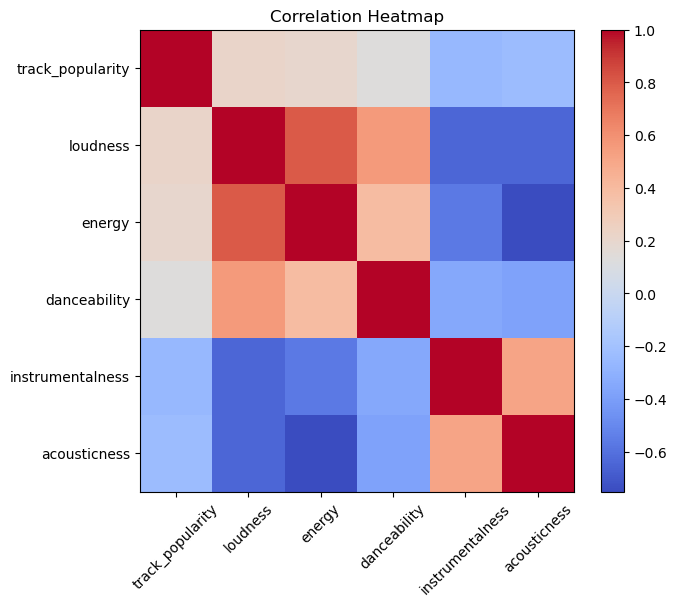

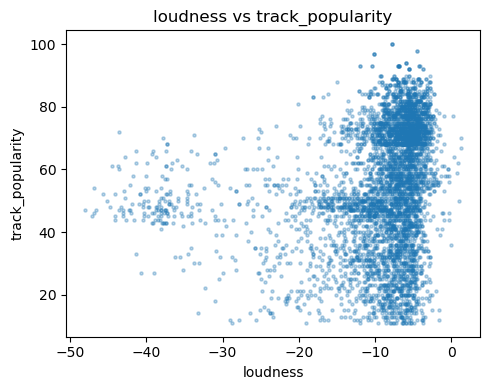

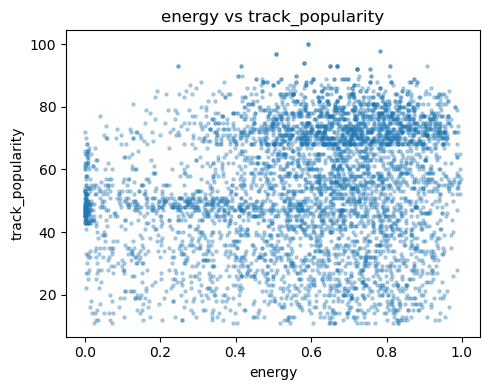

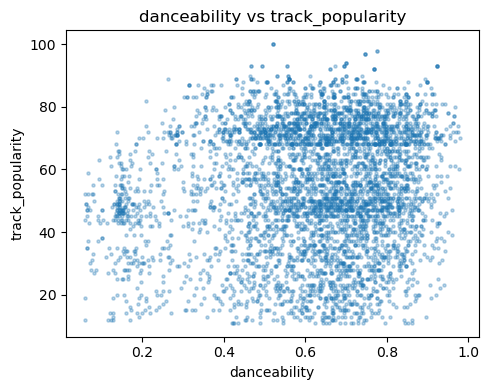

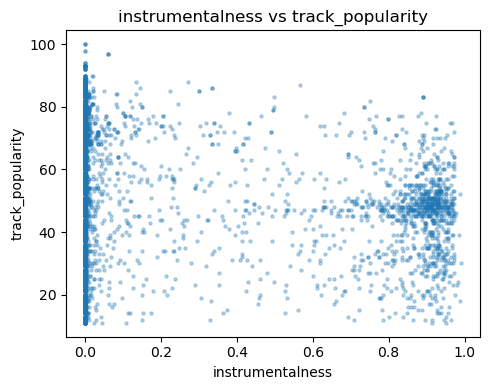

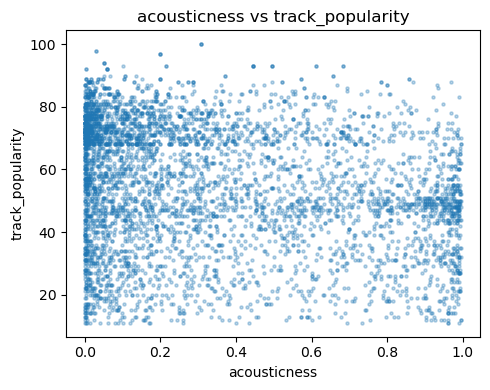

In [8]:
plt.figure(figsize=(7, 6))
corr = df_model[['track_popularity'] + features].corr()
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

#make scatterplots
for col in features:
    plt.figure(figsize=(5, 4))
    plt.scatter(df_model[col], df_model['track_popularity'], alpha=0.3, s=5)
    plt.xlabel(col)
    plt.ylabel('track_popularity')
    plt.title(f'{col} vs track_popularity')
    plt.tight_layout()
    plt.show()

Linear Regression Model

In [9]:
#define X and Y
X = df_model[features]
y = df_model['track_popularity']

#split X and Y into test and training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=1)

In [10]:
#scale only trained data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
#create model
linear_model = LinearRegression()

#5 fold cross validation
kf = KFold(n_splits=5, random_state=1, shuffle=True)

#get predictions
pred = cross_val_predict(linear_model, X_train_scaled, y_train, cv=kf)
pred

array([55.3518944 , 59.56006457, 57.75328957, ..., 56.88348737,
       45.72495741, 56.9645114 ], shape=(3864,))

In [12]:
#get RMSE
linear_rmse = np.sqrt(mean_squared_error(y_train, pred))
print('RMSE:', linear_rmse)
#get r^2
linear_r2 = r2_score(y_train, pred)
print('r^2:', linear_r2)

RMSE: 18.94649988476057
r^2: 0.0780710443971161


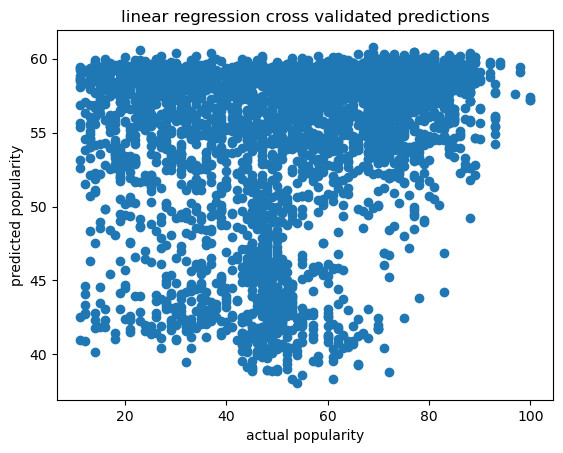

In [13]:
plt.scatter(y_train, pred)
plt.xlabel('actual popularity')
plt.ylabel('predicted popularity')
plt.title('linear regression cross validated predictions')
plt.show()

Polynomial Regression Model

In [14]:
#make polynomial features
poly = PolynomialFeatures(degree=2)
#create polynomial features from scaled data
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [15]:
#make model
poly_model = LinearRegression()
#5 fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)
#get predictions
poly_pred = cross_val_predict(poly_model, X_train_poly, y_train, cv=kf)
poly_pred

array([55.70550353, 61.5293139 , 61.31542966, ..., 54.02843865,
       47.11850246, 63.30962257], shape=(3864,))

In [16]:
#RMSE
poly_rmse = np.sqrt(mean_squared_error(y_train, poly_pred))
print('RMSE:', poly_rmse)
#R^2
poly_r2 = r2_score(y_train, poly_pred)
print('Polynomial R^2:', poly_r2)

RMSE: 18.52515850244508
Polynomial R^2: 0.11861970396171762


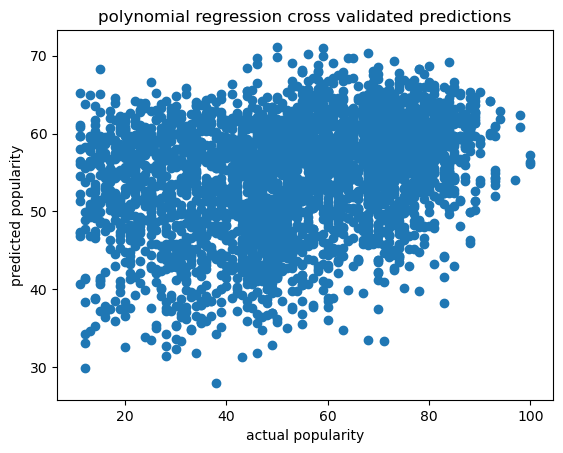

In [17]:
plt.scatter(y_train, poly_pred)
plt.xlabel('actual popularity')
plt.ylabel('predicted popularity')
plt.title('polynomial regression cross validated predictions')
plt.show()

K Nearest Neighbor Model

In [18]:
#define X and Y
X = df_model[features]
y = df_model['track_popularity']

#split into test and training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

#scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#5 fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)
#experiment with different k values
k_values = [5, 10, 15, 20, 25, 30, 35, 40]

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    pred = cross_val_predict(knn, X_train_scaled, y_train, cv=kf)
    rmse = np.sqrt(mean_squared_error(y_train, pred))
    r2 = r2_score(y_train, pred)
    print('KNN k =', k)
    print('RMSE:', rmse)
    print('R^2:', r2)

KNN k = 5
RMSE: 19.669212997946616
R^2: 0.006395753573713803
KNN k = 10
RMSE: 19.051980763545103
R^2: 0.06777715628397218
KNN k = 15
RMSE: 18.868616247330564
R^2: 0.08563503772462466
KNN k = 20
RMSE: 18.768937313907113
R^2: 0.09527031553755505
KNN k = 25
RMSE: 18.76015697842298
R^2: 0.0961166044786258
KNN k = 30
RMSE: 18.724669839065534
R^2: 0.09953298292237034
KNN k = 35
RMSE: 18.719158694415974
R^2: 0.10006296542309145
KNN k = 40
RMSE: 18.69069213632652
R^2: 0.102797984804198


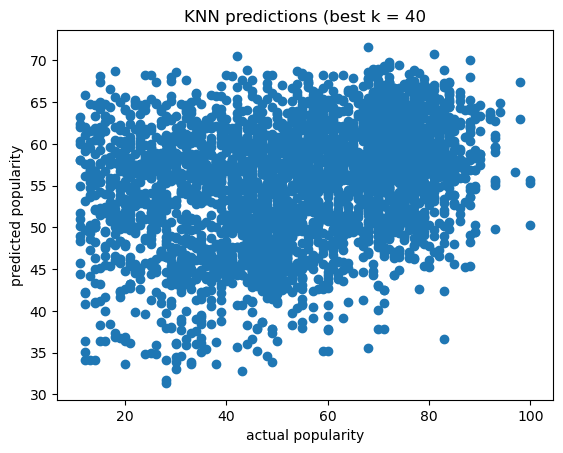

In [19]:
best_k = 40
knn = KNeighborsRegressor(n_neighbors=best_k)
best_pred = cross_val_predict(knn, X_train_scaled, y_train, cv=kf)
plt.figure()
plt.scatter(y_train, best_pred)
plt.xlabel('actual popularity')
plt.ylabel('predicted popularity')
plt.title('KNN predictions (best k = 40')
plt.show()